# PYTHON 5 - LESSON 3
## Data Science Stream - Data Visualiation, Part 2

Author: Magdalena

Date: 08 May 2024

#### Summary
Today we focused on visualising data. We talked about:

1. What are Dashboards? (Examples)

2. More Plots! (with libraries such as matplotlib and seaborn)
    - boxplots
    - pie charts
    - line plots
3. More Functions for DataFrame Manipulation
    - .value_counts()
    - .isna().any()
    - .unique()


#### 1. What are Dashboards? (Examples)

Covid:

https://orosz-attila-covid-19-dashboard-streamlit-app-kmmvgj.streamlit.app

Superstore:

https://superstore-sales-app.streamlit.app
https://public.tableau.com/app/profile/preeth3235/viz/SampleSuperstoreOrdersDashboard/OrderDashboard

Spotify:

https://public.tableau.com/app/profile/laurentiuandrei/viz/PersonalSpotifyStreamingHistoryDashboard/Personal_Spotify_Dashboard

Pollution:

https://public.tableau.com/app/profile/lamazere/viz/Evolutionofairpolution/dashboard

#### The Data

Download the `salaries_by_college_major.csv` file from the course resources and add this file to the notebook by dropping it into the sidebar with the little folder icon.

In [1]:
# Importing libraries
# First, we import all necessary libraries for our analysis.
import pandas as pd
import matplotlib.pyplot as plt  # for data visualisation
import seaborn as sns  # for data visualisation

# Loading the data
df = pd.read_csv('/content/salaries_by_college_major.csv')

# Cleaning the data by dropping rows with missing values
clean_df = df.dropna()

#### 2. More plots!

We'll analyze how starting saleries compare to mid-career saleries across all collge majors. And also how salaries compare across different groups of majors: STEM, HASS, and Business.

In [2]:
# Display the first few rows to remind ourselves of its structure.
clean_df.head()

,Undergraduate Major,Starting Median Salary,Mid-Career Median Salary,Mid-Career 10th Percentile Salary,Mid-Career 90th Percentile Salary,Group
0,Accounting,46000.0,77100.0,42200.0,152000.0,Business
1,Aerospace Engineering,57700.0,101000.0,64300.0,161000.0,STEM
2,Agriculture,42600.0,71900.0,36300.0,150000.0,Business
3,Anthropology,36800.0,61500.0,33800.0,138000.0,HASS
4,Architecture,41600.0,76800.0,50600.0,136000.0,Business


#### BOXPLOT of Starting Salaries by Group
Next, we create a boxplot to compare the starting median salaries across the different groups (STEM, HASS, Business).

{'whiskers': [<matplotlib.lines.Line2D at 0x7cc4da75f910>,
 'caps': [<matplotlib.lines.Line2D at 0x7cc4da75fe50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7cc4da75f6a0>],
 'medians': [<matplotlib.lines.Line2D at 0x7cc4da5a43d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7cc4da5a4670>],
 'means': []}

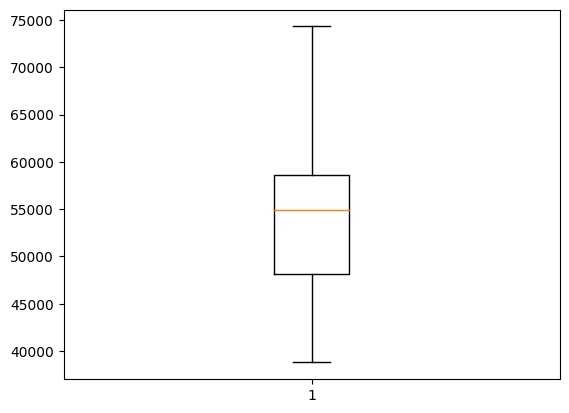

In [3]:
# First let's plot the starting median salary for STEM subjects
# Filter
stem_df = clean_df.loc[clean_df['Group'] == 'STEM']
# Plot with plt.boxplot
plt.boxplot(stem_df['Starting Median Salary'])

# Now try the same for the mid career salary

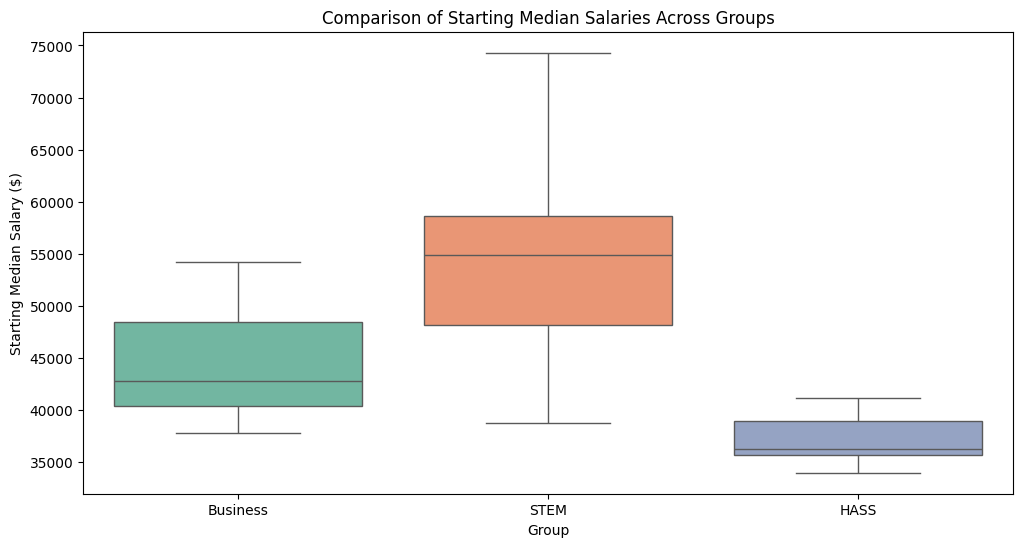

In [4]:
# Compare the different subject groups using seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=clean_df,
    x='Group',
    y='Starting Median Salary',
    hue='Group',
    palette='Set2'
)
plt.title('Comparison of Starting Median Salaries Across Groups')
plt.xlabel('Group')
plt.ylabel('Starting Median Salary ($)')
plt.show()

# Try different colour palettes!
# https://seaborn.pydata.org/tutorial/color_palettes.html

#### PIE CHART of Undergraduate Majors by Group
Lastly, we plot a pie chart to visualize the proportion of undergraduate majors divided into STEM, HASS, and Business groups.

In [5]:
# New method .value_counts()
clean_df['Starting Median Salary'].value_counts()
clean_df['Group'].value_counts()

Group
HASS        22
STEM        16
Business    12
Name: count, dtype: int64

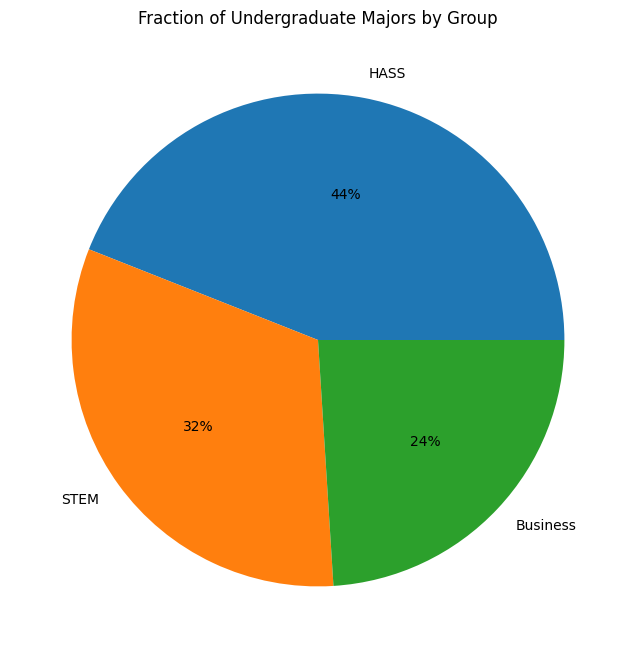

In [6]:
# Count subjects
group_counts = clean_df['Group'].value_counts()

# Plot pie chart with plt.pie
plt.figure(figsize=(8, 8))
plt.pie(group_counts, labels=group_counts.index, autopct='%1.0f%%')
plt.title('Fraction of Undergraduate Majors by Group')
plt.show()

# Adding percentages with autopct='%1.0f%%'

#### New Data! (Air Pollution)

In [7]:
# Loading the data
airpol_df = pd.read_csv('/content/air_pollution_data.csv')

airpol_df.head()

,Year,Continent,SO2 emissions (Million Tonnes)
0,1850,Africa,0.000
1,1860,Africa,0.000
2,1870,Africa,0.000
3,1880,Africa,0.059
4,1890,Africa,0.065


In [8]:
# Checking for NaN values
airpol_df.isna().any()

Year                              False
Continent                         False
SO2 emissions (Million Tonnes)    False
dtype: bool

In [9]:
# Inspecting the data
print(airpol_df.shape)
print(airpol_df['Year'].max())
print(airpol_df['Year'].min())

(85, 3)
2010
1850


In [10]:
# What are the values in the 'Continent' column?

# New method .unique()
airpol_df['Continent'].unique()

array(['Africa', 'Asia', 'Europe', 'North America', 'South America'],
      dtype=object)

#### LINE PLOT of SO2 emissions over the years by continent
We will generate a lineplot where each continent's SO2 emissions trend over the years is plotted with a different color.

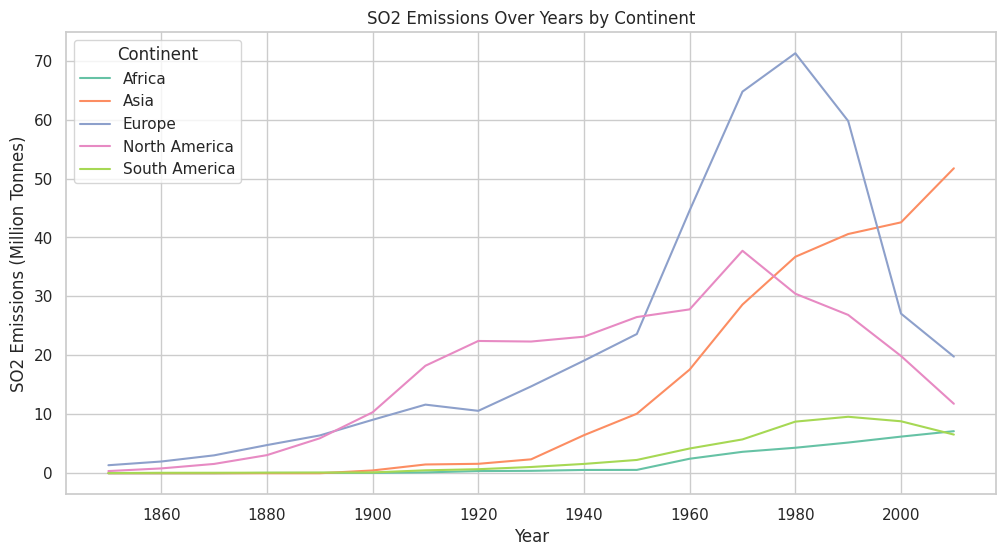

In [11]:
# Make the plot look nicer
sns.set(style="whitegrid")

# Create the lineplot
plt.figure(figsize=(12, 6))
lineplot = sns.lineplot(
    data=airpol_df,
    x='Year',
    y='SO2 emissions (Million Tonnes)',
    hue='Continent',
    palette='Set2'
)

# Adding titles and labels
plt.title('SO2 Emissions Over Years by Continent')
plt.xlabel('Year')
plt.ylabel('SO2 Emissions (Million Tonnes)')
plt.legend(title='Continent')

# Display the plot
plt.show()